In [223]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)

In [224]:
#load the dataset
ds = load_dataset("Mozilla/flickr30k-transformed-captions", split="test")

In [225]:
ds2 = load_dataset("mattymchen/celeba-hq")
ds2 = ds2["train"] 

In [ ]:
#preprocess the dataset

#ex = ds2["train"][100]
print(ds2)
#print(len(ds))
#print(len(ds[0]))
#print(ex.keys())
#ex["image"].show()
#print(ex["alt_text"])
#print(ex["filename"])
#print(ex["alt_text"][0]) #that is only the string

def gen():
    for ex in ds2:
        img = np.array(ex["image"].convert("RGB"))   # (H, W, 3) uint8
        #cap = ex["alt_text"][0]                      # captions
        yield img#, cap                             # make just work this funct for 1 iteration when requested (funct is a generator)

tf_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8)#,
        #tf.TensorSpec(shape=(), dtype=tf.string),
    ),
)

def preprocess(img):#, cap):
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    s = tf.minimum(h, w)
    img = tf.image.resize_with_crop_or_pad(img, s, s)
    img64  = tf.image.resize(img, [64, 64],  method="area")
    img256 = tf.image.resize(img, [256, 256], method="area")
    return {"img64": img64, "img256": img256}#, "caption": cap}

BATCH = 16
pipeline = (
    tf_ds
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

for img in tf_ds.take(1):
    print("image :", img.shape, img.dtype) 
    #print("caption :", cap.numpy())          # cap puts in intelligible letters instead of bytes



Dataset({
    features: ['image', 'label'],
    num_rows: 28000
})
image : (1024, 1024, 3) <dtype: 'uint8'>


In [232]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape = tf.shape(z_mean))
        return z_mean + tf.exp(0.5*z_log_var)*epsilon  # basically sample a single point from the distibution 


In [233]:
#define the VAE model: encoder -> decoder , GAN

encoder_input = layers.Input(shape = (64,64,3),name = "encoder_input")
x = layers.Conv2D(64, (9,9), strides = 2, padding = "same")(encoder_input)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(128, (3,3), strides = 2, padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(256, (3,3), strides = 2, padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(512, (3,3), strides = 2, padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
shape_bf_flat = np.shape(x)
t_, x_, y_, z_ = shape_bf_flat # shape in each dimension
#x = layers.Flatten()(x)
#z_mean = layers.Dense(512, name = "z_mean")(x)
#z_log_var = layers.Dense(512, name = "z_log_var")(x)
z_mean    = layers.Conv2D(64, 3, padding="same", name="z_mean")(x)     # (batch,4,4,16)
z_log_var = layers.Conv2D(64, 3, padding="same", name="z_log_var")(x) # "
encoder_output = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_input,[z_mean, z_log_var, encoder_output], name = "encoder")

decoder_input = layers.Input(shape=(4, 4, 64))     # le latent spatial
x = layers.Conv2D(512, 3, padding="same")(decoder_input)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.UpSampling2D(size = 2, interpolation = "nearest")(x)
x = layers.Conv2D(256 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(256 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.UpSampling2D(size = 2, interpolation = "nearest")(x)
x = layers.Conv2D(128 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(128 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.UpSampling2D(size = 2, interpolation = "nearest")(x)
x = layers.Conv2D(64 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(64 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.UpSampling2D(size = 2, interpolation = "nearest")(x)
x = layers.Conv2D(32 , (3,3), strides = 1 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
decoder_output = layers.Conv2D(3, 3, strides = 1 , padding = "same", activation = "tanh")(x)
decoder = models.Model(decoder_input, decoder_output , name = "decoder")



critic_input = layers.Input(shape = (64,64,3), name = "critic_input")
x = layers.Conv2D(64 , (3, 3), strides = 2, padding = "same")(critic_input)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(128 , (3, 3), strides = 2,padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(256 , (3,3), strides = 2 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Conv2D(512 , (3,3), strides = 2 , padding = "same")(x)
x = layers.GroupNormalization()(x)
x = layers.LeakyReLU(0.3)(x)

critic_output = layers.Conv2D(1,(3,3),strides = 1, padding = "same")(x)
critic = models.Model(critic_input, critic_output, name = "critic")






encoder.summary()
decoder.summary()
critic.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_421 (Conv2D) │ (None, 32, 32,    │     15,616 │ encoder_input[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_421[0][0]  │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_363     │ (None, 32, 32,    │          0 │ group_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_422 (Conv2D) │ (None, 16, 16,    │     73,856 │ leaky_re_lu_363[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_422[0][0]  │
│ (GroupNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_364     │ (None, 16, 16,    │          0 │ group_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_423 (Conv2D) │ (None, 8, 8, 256) │    295,168 │ leaky_re_lu_364[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 8, 8, 256) │        512 │ conv2d_423[0][0]  │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_365     │ (None, 8, 8, 256) │          0 │ group_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_424 (Conv2D) │ (None, 4, 4, 512) │  1,180,160 │ leaky_re_lu_365[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 4, 4, 512) │      1,024 │ conv2d_424[0][0]  │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_366     │ (None, 4, 4, 512) │          0 │ group_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Conv2D)     │ (None, 4, 4, 64)  │    294,976 │ leaky_re_lu_366[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Conv2D)  │ (None, 4, 4, 64)  │    294,976 │ leaky_re_lu_366[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_41         │ (None, 4, 4, 64)  │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,156,672 (8.23 MB)

 Trainable params: 2,156,672 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ critic_input (InputLayer)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_434 (Conv2D)             │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_359         │ (None, 32, 32, 64)     │           128 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_375 (LeakyReLU)     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_435 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_360         │ (None, 16, 16, 128)    │           256 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_376 (LeakyReLU)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_436 (Conv2D)             │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_361         │ (None, 8, 8, 256)      │           512 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_377 (LeakyReLU)     │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_437 (Conv2D)             │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_362         │ (None, 4, 4, 512)      │         1,024 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_378 (LeakyReLU)     │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_438 (Conv2D)             │ (None, 4, 4, 1)        │         4,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,557,505 (5.94 MB)

 Trainable params: 1,557,505 (5.94 MB)

 Non-trainable params: 0 (0.00 B)

In [252]:
#define the train function for VAE -> train step , losses

BETA_KL = 1e-4
LAMBDA_ADV = 0.025

class CRIT_VAE(models.Model):
    def __init__(self, encoder, decoder, critic, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.critic = critic

    def compile(self, vae_opt, critic_opt, **kwargs):
        super().compile(**kwargs)
        self.vae_opt = vae_opt
        self.critic_opt = critic_opt

    def train_step(self, data):
        real_data = data["img64"]

        # 1 train the critic on real and false/generated data
        with tf.GradientTape() as tape:
            mu, log_var, latent = self.encoder(real_data)
            fake_data = self.decoder(latent)
            fake_data = tf.stop_gradient(fake_data)
            crit_pred_false = self.critic(fake_data)
            crit_pred_true = self.critic(real_data)
            crit_loss = tf.reduce_mean(tf.nn.relu(1.-crit_pred_true))+tf.reduce_mean(tf.nn.relu(1.+crit_pred_false))
        gradients = tape.gradient(crit_loss, self.critic.trainable_variables)
        self.critic_opt.apply_gradients(zip(gradients, self.critic.trainable_variables))

        # 2 train the VAE by passing real data through it and through tthe critic to get all the losses
        # Todo : apply LPIPS loss for the VAE
        with tf.GradientTape() as tape:
            mu, log_var, latent = self.encoder(real_data)
            fake_data = self.decoder(latent)
            reconstruction_loss = tf.reduce_mean(tf.abs(real_data - fake_data))
            kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))  # formula from the book ???
            adversive_loss = -tf.reduce_mean(self.critic(fake_data))
            vae_total_loss = reconstruction_loss + BETA_KL * kl_loss + LAMBDA_ADV * adversive_loss
        vars_vae = self.encoder.trainable_variables + self.decoder.trainable_variables
        gradients = tape.gradient(vae_total_loss, vars_vae)
        self.vae_opt.apply_gradients(zip(gradients, vars_vae))

        return {
            "crit_loss": crit_loss,
            "recon": reconstruction_loss,
            "kl": kl_loss,
            "adv": adversive_loss,
        }
    

     

In [253]:
#train the model

crit_vae = CRIT_VAE(encoder, decoder, critic)
crit_vae.compile(vae_opt=tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2= 0.9), critic_opt=tf.keras.optimizers.Adam(2e-4, beta_1=0.5, beta_2= 0.9))
crit_vae.fit(pipeline, epochs = 10)



Epoch 1/10


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 834s 473ms/step - adv: 1.8497 - crit_loss: 0.5290 - kl: 7.6998 - recon: 0.1348
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 867s 495ms/step - adv: 1.4446 - crit_loss: 0.4927 - kl: 7.4593 - recon: 0.1327
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 862s 492ms/step - adv: 1.6596 - crit_loss: 0.7292 - kl: 7.2113 - recon: 0.1309
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 853s 487ms/step - adv: 1.7218 - crit_loss: 0.6011 - kl: 7.3274 - recon: 0.1281
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 851s 486ms/step - adv: 0.4628 - crit_loss: 0.9495 - kl: 7.3108 - recon: 0.1286
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 843s 481ms/step - adv: 2.1546 - crit_loss: 0.7690 - kl: 7.1206 - recon: 0.1267
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 855s 488ms/step - adv: 0.9059 - crit_loss: 0.5602 - kl: 7.1800 - recon: 0.1227
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 841s 480ms/step - adv: 0.5736 - crit_loss: 0.9794 - kl: 7.3481 - recon: 0.1268
Epoch 9/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8

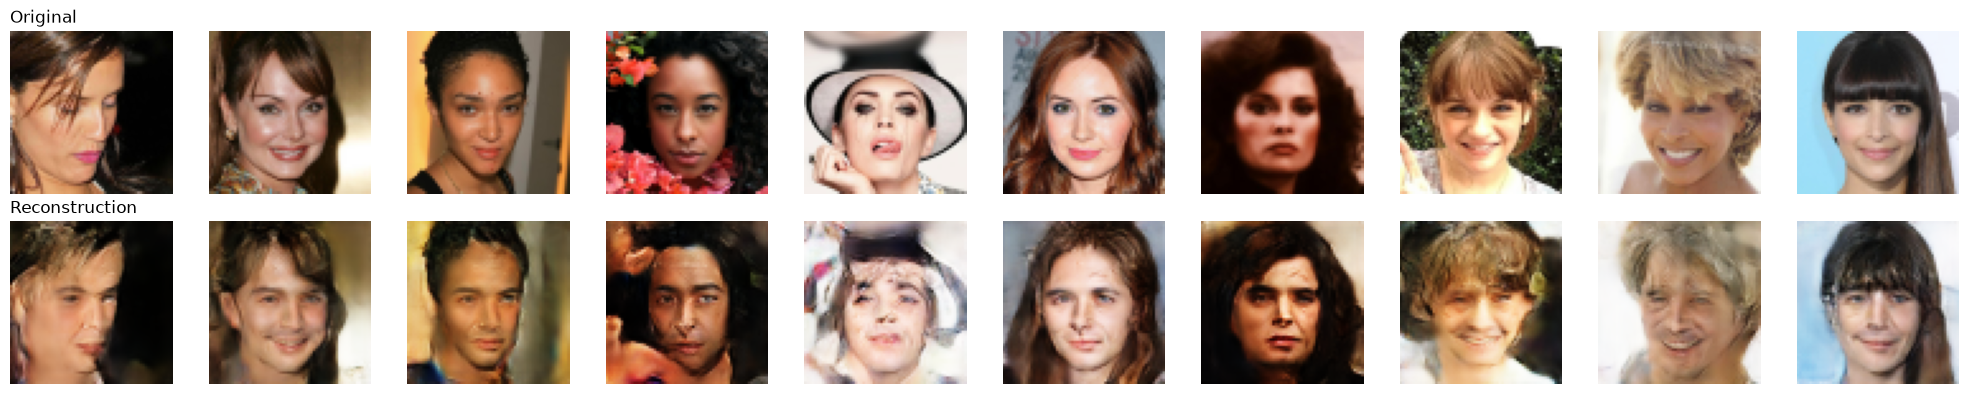

In [254]:
for batch in pipeline.take(1):
    sample = batch        # (10, 64, 64, 3), déjà normalisé en [-1, 1]
    break

# --- 2. passer dans le VAE ---
mu, log_var, latent = encoder(sample["img64"])
recon = decoder(latent)

# --- 3. dénormaliser [-1,1] -> [0,1] pour l'affichage ---
def to_display(x):
    x = (x + 1.0) / 2.0                 # [-1,1] -> [0,1]
    return np.clip(x.numpy() if hasattr(x, "numpy") else x, 0, 1)

originals = to_display(sample["img64"])
recons    = to_display(recon)

# --- 4. afficher : ligne du haut = original, ligne du bas = reconstruction ---
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(originals[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", loc="left")
    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recons[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstruction", loc="left")

plt.tight_layout()
plt.show()

In [256]:
encoder.save_weights("encoder.weights.h5")
decoder.save_weights("decoder.weights.h5")
critic.save_weights("critic.weights.h5")

In [ ]:
#define the diffusion model and text encoder

In [ ]:
#define the train function for diffusion and embedding model -> train step , losses ...

In [ ]:
#train the model

In [ ]:
#define the function for generation